# Clustering des données immobilières californiennes
## Bloc IA — Prosit 1

Ce notebook implémente le pipeline de clustering :
1. Chargement et nettoyage des données
2. Sélection des variables
3. Détermination de k par CAH (dendrogramme)
4. Méthode du coude (Elbow Method) — WCSS
5. KMeans (k=6)
6. Visualisation et export du dataset transformé

## 1. Chargement et exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (12, 8)
sns.set()
sns.set_context('talk')

In [2]:
# Chargement du dataset imputé par KNN
housing = pd.read_csv('./data/housing_data_knn.csv')
print(f"Shape : {housing.shape}")
housing.head()

Shape : (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
# Valeurs manquantes
housing.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## 2. Préparation du dataset

1. **Variables utilisées** : toutes sauf `latitude` et `longitude` (position géographique exclue).
2. **`ocean_proximity`** est encodée via `LabelEncoder` pour la rendre numérique.
3. **Pas de standardisation** : les données brutes sont utilisées directement.
4. **Pas de suppression d'outliers**.

In [5]:
# Encodage de ocean_proximity
le = LabelEncoder()
housing['ocean_proximity_encoded'] = le.fit_transform(housing['ocean_proximity'])
print("Mapping ocean_proximity :")
for i, label in enumerate(le.classes_):
    print(f"  {label} → {i}")

# Variables pour le clustering (sans latitude/longitude)
features = ['housing_median_age', 'total_rooms',
            'total_bedrooms', 'population', 'households', 'median_income',
            'median_house_value', 'ocean_proximity_encoded']
X = housing[features].copy()

print(f"\nValeurs manquantes : {X.isnull().sum().sum()}")
print(f"Shape : {X.shape}")

Mapping ocean_proximity :
  <1H OCEAN → 0
  INLAND → 1
  ISLAND → 2
  NEAR BAY → 3
  NEAR OCEAN → 4

Valeurs manquantes : 0
Shape : (20640, 8)


## 3. Détermination de k par CAH (dendrogramme)

# CAH sur un échantillon de 2000 points (performance)
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=2000, replace=False)
X_sample = X.values[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.xlabel('Échantillons')
plt.ylabel('Distance (Ward)')
plt.title('Dendrogramme CAH (méthode de Ward) — toutes variables')
plt.tight_layout()
plt.show()

In [6]:
# Calcul du WCSS pour k de 2 à 15
k_range = range(2, 16)
wcss = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    print(f"k={k:2d}  WCSS={kmeans.inertia_:.0f}")

k= 2  WCSS=85983799818637
k= 3  WCSS=39117745405552
k= 4  WCSS=21326221029786
k= 5  WCSS=12398368478432
k= 6  WCSS=8833848832553
k= 7  WCSS=6544692882323
k= 8  WCSS=4966154668407
k= 9  WCSS=3813072364527
k=10  WCSS=3169392145169
k=11  WCSS=2582451046130
k=12  WCSS=2182853672288
k=13  WCSS=1866540273098
k=14  WCSS=1593626484241
k=15  WCSS=1415041582744


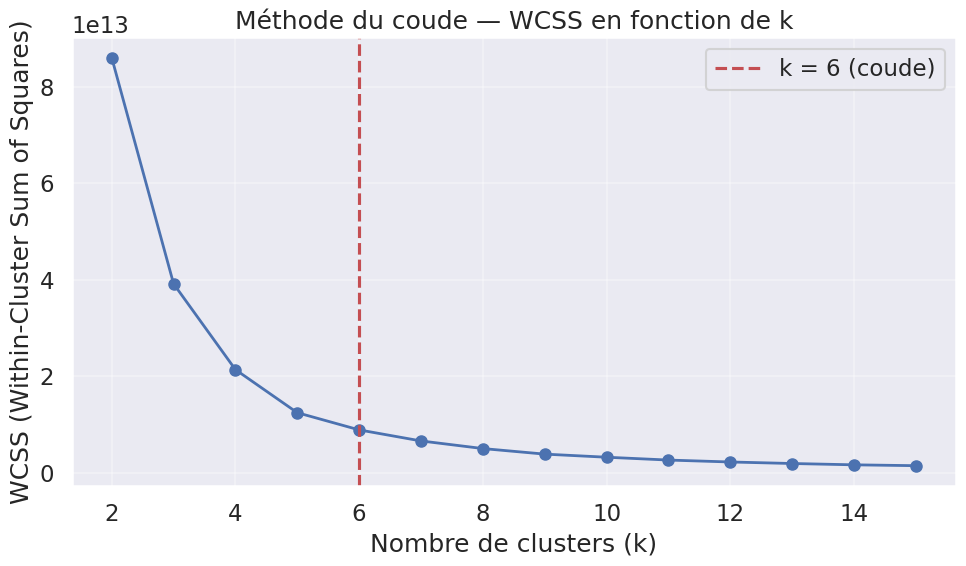

In [7]:
# Tracé de la courbe du coude
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), wcss, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=6, color='r', linestyle='--', label='k = 6 (coude)')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Méthode du coude — WCSS en fonction de k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Le dendrogramme et la courbe du coude convergent vers **k = 5**.

## 5. KMeans avec k = 5

In [8]:
# KMeans final
kmeans_final = KMeans(n_clusters=5, n_init=10, random_state=42)
clusters = kmeans_final.fit_predict(X)

# Ajout de la colonne cluster au dataframe original
housing['cluster'] = clusters

print("Répartition des clusters :")
print(housing['cluster'].value_counts().sort_index())

Répartition des clusters :
cluster
0    5731
1    4534
2    1613
3    6446
4    2316
Name: count, dtype: int64


In [9]:
# Statistiques par cluster
cluster_stats = housing.groupby('cluster').agg(
    effectif=('cluster', 'size'),
    prix_moyen=('median_house_value', 'mean'),
    revenu_moyen=('median_income', 'mean'),
    lat_moyenne=('latitude', 'mean'),
    lon_moyenne=('longitude', 'mean')
).round(2)

cluster_stats

,effectif,prix_moyen,revenu_moyen,lat_moyenne,lon_moyenne
cluster,,,,,
0,5731,90084.00,2.50,36.42,-119.68
1,4534,245457.01,4.35,35.36,-119.67
2,1613,480483.86,7.02,35.29,-119.75
3,6446,164721.83,3.47,35.27,-119.24
4,2316,346940.07,5.24,35.48,-119.89


## 6. Visualisation géographique des clusters

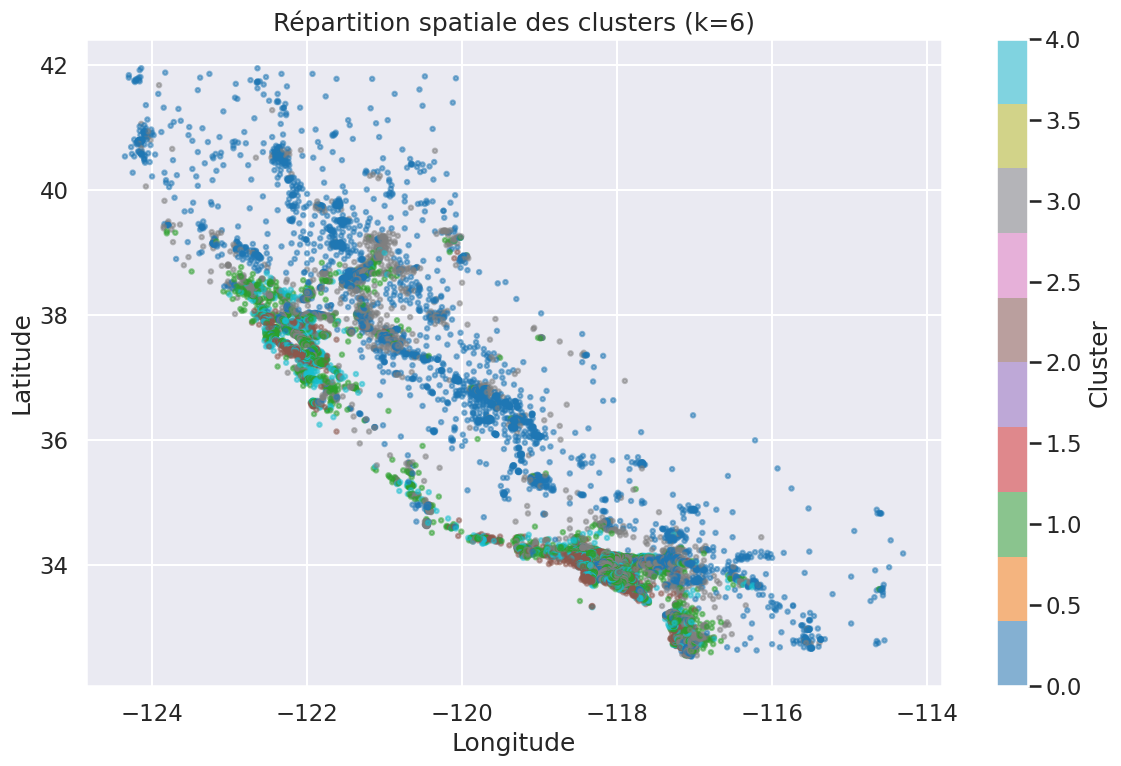

In [10]:
# Scatter plot latitude vs longitude coloré par cluster
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    housing['longitude'], housing['latitude'],
    c=housing['cluster'], cmap='tab10',
    alpha=0.5, s=10
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Répartition spatiale des clusters (k=6)')
plt.tight_layout()
plt.show()

In [11]:
# Export avec la colonne cluster ajoutée (sans ocean_proximity_encoded)
housing_out = housing.drop(columns=['ocean_proximity_encoded'])
output_path = './data/housing_data_knn_clustered.csv'
housing_out.to_csv(output_path, index=False)
print(f"Dataset exporté : {output_path}")
print(f"Shape : {housing_out.shape}")
housing_out.head()

Dataset exporté : ./data/housing_data_knn_clustered.csv
Shape : (20640, 11)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,cluster
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,2
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,4
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,4
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,4


## Résumé du pipeline

| Étape | Description |
|-------|-------------|
| 1 | Chargement de `housing_data_knn.csv` (20 640 lignes, 10 colonnes, imputé par KNN) |
| 2 | Encodage de `ocean_proximity` via LabelEncoder |
| 3 | Détermination de k par CAH (dendrogramme de Ward) |
| 4 | Validation par méthode du coude (WCSS) → k=5 |
| 5 | KMeans (k=5) sur toutes les variables → ajout de la colonne `cluster` |
| 6 | Export → `housing_data_knn_clustered.csv` (20 640 lignes, 11 colonnes) |